In [1]:
# Import required libraries
import json
import pathlib
import numpy as np
import torch
import h5py
from PIL import Image
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

# ARTIST imports
from artist.scenario.scenario import Scenario
from artist.core.heliostat_ray_tracer import HeliostatRayTracer
from artist.util import config_dictionary, set_logger_config, index_mapping
from artist.util.environment_setup import get_device

# Set up logger
set_logger_config()

# Set device
device = get_device()
print(f"Using device: {device}")

[2025-12-26 11:27:01,289][artist.util.environment_setup][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2025-12-26 11:27:01,289][artist.util.environment_setup][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
Using device: cpu


In [2]:
# Define paths to data
DATA_DIR = pathlib.Path("paint_data")
TOWER_FILE = DATA_DIR / "tower-measurements.json"
HELIOSTAT_ID = "AA31"
HELIOSTAT_DIR = DATA_DIR / HELIOSTAT_ID
CALIBRATION_DIR = HELIOSTAT_DIR / "Calibration"
HELIOSTAT_PROPERTIES = HELIOSTAT_DIR / "Properties" / "AA31-heliostat-properties.json"

# Target receiver we're training for
TARGET_NAME = "solar_tower_juelich_lower"

print(f"Data directory: {DATA_DIR}")
print(f"Heliostat: {HELIOSTAT_ID}")
print(f"Target receiver: {TARGET_NAME}")
print(f"Calibration directory: {CALIBRATION_DIR}")
print(f"Heliostat properties: {HELIOSTAT_PROPERTIES}")

Data directory: paint_data
Heliostat: AA31
Target receiver: solar_tower_juelich_lower
Calibration directory: paint_data/AA31/Calibration
Heliostat properties: paint_data/AA31/Properties/AA31-heliostat-properties.json


In [3]:
# GPS to ENU conversion function
def gps_to_enu(lat, lon, alt, origin_lat, origin_lon, origin_alt):
    """
    Convert GPS (WGS84) coordinates to local ENU (East-North-Up) coordinates.
    
    Args:
        lat, lon, alt: Target GPS coordinates
        origin_lat, origin_lon, origin_alt: Origin GPS coordinates
        
    Returns:
        numpy array [E, N, U] in meters
    """
    # Convert degrees to radians
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    origin_lat_rad = np.radians(origin_lat)
    origin_lon_rad = np.radians(origin_lon)
    
    # WGS84 ellipsoid parameters
    a = 6378137.0  # semi-major axis in meters
    f = 1 / 298.257223563  # flattening
    e2 = 2 * f - f ** 2  # first eccentricity squared
    
    # Radius of curvature in the prime vertical
    N_origin = a / np.sqrt(1 - e2 * np.sin(origin_lat_rad) ** 2)
    N_target = a / np.sqrt(1 - e2 * np.sin(lat_rad) ** 2)
    
    # Convert to ECEF (Earth-Centered Earth-Fixed)
    X_origin = (N_origin + origin_alt) * np.cos(origin_lat_rad) * np.cos(origin_lon_rad)
    Y_origin = (N_origin + origin_alt) * np.cos(origin_lat_rad) * np.sin(origin_lon_rad)
    Z_origin = (N_origin * (1 - e2) + origin_alt) * np.sin(origin_lat_rad)
    
    X_target = (N_target + alt) * np.cos(lat_rad) * np.cos(lon_rad)
    Y_target = (N_target + alt) * np.cos(lat_rad) * np.sin(lon_rad)
    Z_target = (N_target * (1 - e2) + alt) * np.sin(lat_rad)
    
    # Difference in ECEF
    dX = X_target - X_origin
    dY = Y_target - Y_origin
    dZ = Z_target - Z_origin
    
    # Rotation matrix from ECEF to ENU
    E = -np.sin(origin_lon_rad) * dX + np.cos(origin_lon_rad) * dY
    N = -np.sin(origin_lat_rad) * np.cos(origin_lon_rad) * dX - np.sin(origin_lat_rad) * np.sin(origin_lon_rad) * dY + np.cos(origin_lat_rad) * dZ
    U = np.cos(origin_lat_rad) * np.cos(origin_lon_rad) * dX + np.cos(origin_lat_rad) * np.sin(origin_lon_rad) * dY + np.sin(origin_lat_rad) * dZ
    
    return np.array([E, N, U])

# Test the function
print("GPS to ENU conversion function defined")

GPS to ENU conversion function defined


In [4]:
# Load tower measurements to get power plant origin and target positions
with open(TOWER_FILE) as f:
    tower_data = json.load(f)

# Extract power plant GPS coordinates (will be our origin)
power_plant_gps = tower_data['power_plant_properties']['coordinates']
origin_lat, origin_lon, origin_alt = power_plant_gps

print(f"Power plant position (origin): lat={origin_lat}, lon={origin_lon}, alt={origin_alt}m")

# Extract target solar_tower_juelich_lower center position and convert to ENU
target_center_gps = tower_data['solar_tower_juelich_lower']['coordinates']['center']
target_lat, target_lon, target_alt = target_center_gps

target_enu = gps_to_enu(target_lat, target_lon, target_alt, origin_lat, origin_lon, origin_alt)

print(f"Target (solar_tower_juelich_lower) GPS: lat={target_lat}, lon={target_lon}, alt={target_alt}m")
print(f"Target ENU position: E={target_enu[0]:.2f}, N={target_enu[1]:.2f}, U={target_enu[2]:.2f}")

Power plant position (origin): lat=50.9134211225926, lon=6.38782475587486, alt=87m
Target (solar_tower_juelich_lower) GPS: lat=50.91339203684, lon=6.38782456351324, alt=122.8815m
Target ENU position: E=-0.01, N=-3.24, U=35.88


In [5]:
# Load all calibration measurements for AA31 targeting solar_tower_juelich_lower
def load_calibration_measurements(calibration_dir, target_name, heliostat_properties_path):
    """
    Load all calibration measurements from the paint_data folder.
    
    Args:
        calibration_dir: Path to Calibration folder containing measurement subfolders
        target_name: Target receiver name to filter by (e.g., 'solar_tower_juelich_lower')
        heliostat_properties_path: Path to heliostat properties JSON file
        
    Returns:
        List of dictionaries containing measurement data
    """
    # Load heliostat properties once (same for all measurements)
    with open(heliostat_properties_path) as f:
        heliostat_data = json.load(f)
    heliostat_gps = heliostat_data['heliostat_position']
    
    # Get heliostat ENU position relative to power plant
    heliostat_enu = gps_to_enu(
        heliostat_gps[0], heliostat_gps[1], heliostat_gps[2],
        origin_lat, origin_lon, origin_alt
    )
    
    measurements = []
    
    # Iterate through all measurement folders
    measurement_dirs = sorted([d for d in calibration_dir.iterdir() if d.is_dir()])
    
    for measurement_dir in measurement_dirs:
        properties_file = measurement_dir / "properties.json"
        flux_file = measurement_dir / "flux.png"
        
        # Check if both files exist
        if not properties_file.exists() or not flux_file.exists():
            continue
        
        # Load properties
        with open(properties_file) as f:
            props = json.load(f)
        
        # Filter by target name
        if props.get('target_name') != target_name:
            continue
        
        # Load flux image
        flux_img = Image.open(flux_file).convert('L')
        flux_array = np.array(flux_img, dtype=np.float32) / 255.0  # Normalize to [0, 1]
        
        # Store measurement data
        measurements.append({
            'measurement_id': measurement_dir.name,
            'sun_elevation': props['sun_elevation'],
            'sun_azimuth': props['sun_azimuth'],
            'motor_1': props['motor_position']['axis_1_motor_position'],
            'motor_2': props['motor_position']['axis_2_motor_position'],
            'heliostat_enu': heliostat_enu,
            'target_enu': target_enu,
            'flux_image': flux_array,
        })
    
    return measurements

# Load all measurements
print(f"Loading calibration measurements from {CALIBRATION_DIR}...")
print(f"Filtering for target: {TARGET_NAME}")

all_measurements = load_calibration_measurements(
    calibration_dir=CALIBRATION_DIR,
    target_name=TARGET_NAME,
    heliostat_properties_path=HELIOSTAT_PROPERTIES
)

print(f"\nLoaded {len(all_measurements)} measurements targeting {TARGET_NAME}")

# Show statistics
if len(all_measurements) > 0:
    sun_elevations = [m['sun_elevation'] for m in all_measurements]
    sun_azimuths = [m['sun_azimuth'] for m in all_measurements]
    motor_1_values = [m['motor_1'] for m in all_measurements]
    motor_2_values = [m['motor_2'] for m in all_measurements]
    
    print(f"\nDataset statistics:")
    print(f"  Sun elevation: {min(sun_elevations):.1f}° to {max(sun_elevations):.1f}°")
    print(f"  Sun azimuth: {min(sun_azimuths):.1f}° to {max(sun_azimuths):.1f}°")
    print(f"  Motor 1: {min(motor_1_values)} to {max(motor_1_values)} increments")
    print(f"  Motor 2: {min(motor_2_values)} to {max(motor_2_values)} increments")
    print(f"  Heliostat ENU position: {all_measurements[0]['heliostat_enu']}")
    print(f"  Target ENU position: {all_measurements[0]['target_enu']}")
else:
    print(f"⚠️ No measurements found for target {TARGET_NAME}")

Loading calibration measurements from paint_data/AA31/Calibration...
Filtering for target: solar_tower_juelich_lower

Loaded 53 measurements targeting solar_tower_juelich_lower

Dataset statistics:
  Sun elevation: 13.0° to 61.5°
  Sun azimuth: -97.7° to 84.2°
  Motor 1: 20120 to 46136 increments
  Motor 2: 10428 to 60240 increments
  Heliostat ENU position: [-23.52598878  24.8462733    1.67156965]
  Target ENU position: [-1.35287227e-02 -3.23575400e+00  3.58814992e+01]


In [6]:
# Train-test split: 80-20
import random

# Set random seed for reproducibility
random.seed(42)

# Shuffle measurements
shuffled_measurements = all_measurements.copy()
random.shuffle(shuffled_measurements)

# Calculate split index (80% train, 20% test)
split_index = int(len(shuffled_measurements) * 0.8)

train_samples = shuffled_measurements[:split_index]
test_samples = shuffled_measurements[split_index:]

print(f"Dataset split (80-20):")
print(f"  Training samples: {len(train_samples)}")
print(f"  Test samples: {len(test_samples)}")
print(f"  Total: {len(all_measurements)}")

# Show first few measurement IDs from each split
print(f"\nFirst 5 training measurement IDs:")
for sample in train_samples[:5]:
    print(f"  - {sample['measurement_id']} (sun_elev={sample['sun_elevation']:.1f}°, sun_azim={sample['sun_azimuth']:.1f}°)")

print(f"\nFirst 5 test measurement IDs:")
for sample in test_samples[:5]:
    print(f"  - {sample['measurement_id']} (sun_elev={sample['sun_elevation']:.1f}°, sun_azim={sample['sun_azimuth']:.1f}°)")

Dataset split (80-20):
  Training samples: 42
  Test samples: 11
  Total: 53

First 5 training measurement IDs:
  - 142314 (sun_elev=59.3°, sun_azim=-18.2°)
  - 162578 (sun_elev=32.7°, sun_azim=-58.4°)
  - 171007 (sun_elev=30.7°, sun_azim=-24.4°)
  - 123875 (sun_elev=52.9°, sun_azim=54.2°)
  - 157267 (sun_elev=41.0°, sun_azim=-58.0°)

First 5 test measurement IDs:
  - 213875 (sun_elev=60.9°, sun_azim=14.8°)
  - 244054 (sun_elev=35.1°, sun_azim=50.8°)
  - 133732 (sun_elev=46.5°, sun_azim=66.8°)
  - 137978 (sun_elev=46.6°, sun_azim=66.0°)
  - 147341 (sun_elev=39.7°, sun_azim=-71.1°)


## Prepare Dataset for Network

Now we'll prepare the data in the format needed for the neural network:
- **Inputs:** Sun angles (2) + Heliostat position (3) + Tower position (3) + Target position (3) + Flux image (256x256 flattened) = 65547 features
- **Outputs:** Motor positions (2)

## Make the dataset loadable for the training using torch

In [7]:
# Create PyTorch Dataset class for single heliostat motor position prediction
from torch.utils.data import Dataset, DataLoader

class HeliostatMotorDataset(Dataset):
    """Dataset for heliostat motor position prediction with flux image as input."""
    
    def __init__(self, samples_list):
        """
        Args:
            samples_list: List of sample dictionaries from load_calibration_measurements()
        """
        self.samples = samples_list
        
        # Compute normalization statistics from the samples
        self._compute_normalization_stats()
        
    def _compute_normalization_stats(self):
        """Compute min/max for normalization."""
        # Sun angles - use reasonable bounds
        self.sun_elev_min, self.sun_elev_max = 0.0, 90.0  # degrees
        self.sun_azim_min, self.sun_azim_max = -180.0, 180.0  # degrees
        
        # Motor positions - compute from data
        all_motor_1 = [s['motor_1'] for s in self.samples]
        all_motor_2 = [s['motor_2'] for s in self.samples]
        self.motor_1_min, self.motor_1_max = min(all_motor_1), max(all_motor_1)
        self.motor_2_min, self.motor_2_max = min(all_motor_2), max(all_motor_2)
        
        print(f"Normalization statistics:")
        print(f"  Sun elevation: [{self.sun_elev_min}, {self.sun_elev_max}]")
        print(f"  Sun azimuth: [{self.sun_azim_min}, {self.sun_azim_max}]")
        print(f"  Motor 1: [{self.motor_1_min}, {self.motor_1_max}]")
        print(f"  Motor 2: [{self.motor_2_min}, {self.motor_2_max}]")
    
    def normalize(self, value, min_val, max_val):
        """Normalize value to [0, 1] range."""
        if max_val - min_val == 0:
            return 0.5
        return (value - min_val) / (max_val - min_val)
    
    def denormalize_motors(self, motor_1_norm, motor_2_norm):
        """Denormalize motor positions from [0, 1] back to increments."""
        motor_1 = motor_1_norm * (self.motor_1_max - self.motor_1_min) + self.motor_1_min
        motor_2 = motor_2_norm * (self.motor_2_max - self.motor_2_min) + self.motor_2_min
        return motor_1, motor_2
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Normalize geometric inputs (sun angles only for single heliostat)
        sun_elev_norm = self.normalize(sample['sun_elevation'], self.sun_elev_min, self.sun_elev_max)
        sun_azim_norm = self.normalize(sample['sun_azimuth'], self.sun_azim_min, self.sun_azim_max)
        
        # Geometric features: just sun angles [2 features]
        geometric_features = np.array([sun_elev_norm, sun_azim_norm])
        
        # Flux image: already normalized to [0, 1] during loading
        # Flatten from [256, 256] to [65536]
        flux_flattened = sample['flux_image'].flatten()
        
        # Concatenate geometric features + flattened flux image
        # Total: 2 + 65536 = 65538 features
        full_inputs = np.concatenate([geometric_features, flux_flattened])
        
        # Normalize motor positions (outputs)
        motor_1_norm = self.normalize(sample['motor_1'], self.motor_1_min, self.motor_1_max)
        motor_2_norm = self.normalize(sample['motor_2'], self.motor_2_min, self.motor_2_max)
        outputs = np.array([motor_1_norm, motor_2_norm])
        
        # Convert to PyTorch tensors
        inputs_tensor = torch.tensor(full_inputs, dtype=torch.float32)
        outputs_tensor = torch.tensor(outputs, dtype=torch.float32)
        
        return {
            'inputs': inputs_tensor,           # [65538] = 2 sun angles + 65536 flux pixels
            'motor_positions': outputs_tensor, # [2]
            'metadata': {
                'measurement_id': sample['measurement_id'],
                'sun_elevation': sample['sun_elevation'],
                'sun_azimuth': sample['sun_azimuth'],
            }
        }

print("HeliostatMotorDataset class defined")

HeliostatMotorDataset class defined


In [8]:
# Create datasets for train and test splits
train_dataset = HeliostatMotorDataset(train_samples)
test_dataset = HeliostatMotorDataset(test_samples)

print(f"\nDataset created:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

# Test loading one sample
sample = train_dataset[0]
print(f"\nSample data shapes:")
print(f"  Inputs: {sample['inputs'].shape}")
print(f"  Motor positions: {sample['motor_positions'].shape}")
print(f"\nInput breakdown:")
print(f"  Geometric features (first 11): {sample['inputs'][:11]}")
print(f"  Flux pixels (65536 total, showing first 5): {sample['inputs'][11:16]}")
print(f"  Motor positions (normalized): {sample['motor_positions']}")


Normalization statistics:
  Sun elevation: [0.0, 90.0]
  Sun azimuth: [-180.0, 180.0]
  Motor 1: [20120, 46136]
  Motor 2: [10428, 60240]
Normalization statistics:
  Sun elevation: [0.0, 90.0]
  Sun azimuth: [-180.0, 180.0]
  Motor 1: [20852, 41084]
  Motor 2: [17883, 57915]

Dataset created:
  Training samples: 42
  Test samples: 11

Sample data shapes:
  Inputs: torch.Size([65538])
  Motor positions: torch.Size([2])

Input breakdown:
  Geometric features (first 11): tensor([0.6584, 0.4495, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000])
  Flux pixels (65536 total, showing first 5): tensor([0., 0., 0., 0., 0.])
  Motor positions (normalized): tensor([0.3834, 0.5486])


In [9]:
# Create DataLoaders
# Note: batch_size=1 since we only have 2 training samples
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("DataLoaders created")
print(f"  Train batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test loading a batch
for batch in train_loader:
    print(f"\nBatch shapes:")
    print(f"  Inputs: {batch['inputs'].shape}")  # [batch_size, 65547]
    print(f"  Motor positions: {batch['motor_positions'].shape}")  # [batch_size, 2]
    break


DataLoaders created
  Train batches: 42
  Test batches: 11

Batch shapes:
  Inputs: torch.Size([1, 65538])
  Motor positions: torch.Size([1, 2])


## Define Neural Network

Simple feedforward network for motor position prediction:
- **Input:** 65,538 features (2 sun angles + 65,536 flux pixels)
- **Hidden layers:** 256 → 128 → 64 neurons
- **Output:** 2 motor positions (normalized to [0, 1])
- **Activation:** ReLU for hidden layers, Sigmoid for output

In [10]:
import torch.nn as nn

class MotorPositionPredictor(nn.Module):
    """Simple feedforward neural network for motor position prediction."""
    
    def __init__(self, input_dim=65538, hidden_dim1=256, hidden_dim2=128, hidden_dim3=64, output_dim=2):
        super(MotorPositionPredictor, self).__init__()
        
        self.network = nn.Sequential(
            # Input layer → First hidden layer
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            
            # First hidden → Second hidden layer
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            
            # Second hidden → Third hidden layer
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            
            # Third hidden → Output layer
            nn.Linear(hidden_dim3, output_dim),
            nn.Sigmoid()  # Output in [0, 1] for normalized motor positions
        )
    
    def forward(self, x):
        """
        Forward pass through the network.
        
        Args:
            x: Input tensor of shape [batch_size, 65538]
            
        Returns:
            Predicted motor positions of shape [batch_size, 2]
        """
        return self.network(x)

print("MotorPositionPredictor network defined")

MotorPositionPredictor network defined


In [11]:
# Instantiate the network and move to device
model = MotorPositionPredictor().to(device)

# Print network architecture
print(f"\nNetwork architecture:")
print(model)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Network architecture:
MotorPositionPredictor(
  (network): Sequential(
    (0): Linear(in_features=65538, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 16,819,266
Trainable parameters: 16,819,266


In [12]:
# Test forward pass with one batch
test_batch = next(iter(train_loader))
test_input = test_batch['inputs'].to(device)
test_output = model(test_input)

print(f"\nTest forward pass:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Output values (normalized motor positions): {test_output.squeeze().detach().cpu().numpy()}")

# Denormalize to get actual motor positions
motor_1_norm, motor_2_norm = test_output.squeeze().detach().cpu().numpy()
motor_1_actual, motor_2_actual = train_dataset.denormalize_motors(motor_1_norm, motor_2_norm)
print(f"  Denormalized motor positions: [{motor_1_actual:.0f}, {motor_2_actual:.0f}] increments")


Test forward pass:
  Input shape: torch.Size([1, 65538])
  Output shape: torch.Size([1, 2])
  Output values (normalized motor positions): [0.46598914 0.50641483]
  Denormalized motor positions: [32243, 35654] increments


## Helper Functions for ARTIST Integration

Before training, we need helper functions to:
1. Convert sun angles to incident ray directions
2. Set up ARTIST scenario and raytracer

In [13]:
def sun_angles_to_incident_ray_direction(elevation_deg, azimuth_deg):
    """
    Convert sun elevation and azimuth angles to incident ray direction.
    
    Args:
        elevation_deg: Sun elevation angle in degrees (0° = horizon, 90° = zenith)
        azimuth_deg: Sun azimuth angle in degrees (0° = north, 90° = east, 180° = south, -90° = west)
        
    Returns:
        torch.Tensor: Incident ray direction [dx, dy, dz, 0] normalized
    """
    # Convert to radians
    elevation_rad = np.radians(elevation_deg)
    azimuth_rad = np.radians(azimuth_deg)
    
    # Convert spherical to Cartesian coordinates
    # The incident ray direction points FROM the sun TO the heliostat
    # In ENU coordinates:
    # - E (east) is x-axis
    # - N (north) is y-axis
    # - U (up) is z-axis
    
    # Compute direction components
    dx = np.sin(azimuth_rad) * np.cos(elevation_rad)  # East component
    dy = np.cos(azimuth_rad) * np.cos(elevation_rad)  # North component
    dz = -np.sin(elevation_rad)  # Up component (negative because rays come DOWN from sun)
    
    # Create direction vector [dx, dy, dz, 0]
    direction = np.array([dx, dy, dz, 0.0])
    
    # Normalize
    norm = np.sqrt(dx**2 + dy**2 + dz**2)
    direction[:3] = direction[:3] / norm
    
    return torch.tensor(direction, dtype=torch.float32)

# Test the function
test_elevation = 50.56  # degrees
test_azimuth = 59.79    # degrees
test_direction = sun_angles_to_incident_ray_direction(test_elevation, test_azimuth)
print(f"Sun angles: elevation={test_elevation}°, azimuth={test_azimuth}°")
print(f"Incident ray direction: {test_direction.numpy()}")
print(f"Direction magnitude (should be ~1.0): {torch.norm(test_direction[:3]).item():.6f}")

Sun angles: elevation=50.56°, azimuth=59.79°
Incident ray direction: [ 0.5489919   0.31964922 -0.7722903   0.        ]
Direction magnitude (should be ~1.0): 1.000000


## Dataset Class for PyTorch

Now we'll create a PyTorch Dataset class to handle the calibration measurements.

In [14]:
# This cell is no longer needed - we're using the pre-generated scenario file

In [15]:
# This cell is no longer needed - we're using the pre-generated scenario file

## Training Configuration and Setup

Define training parameters and set up the optimizer.

In [16]:
# Training parameters
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100
LOG_INTERVAL = 5

# Create optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = torch.nn.MSELoss()  # Simple MSE loss for flux images

# You can also use ARTIST's loss functions:
# from artist.core.loss_functions import KLDivergenceLoss
# loss_fn = KLDivergenceLoss()

print(f"Training configuration:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Number of epochs: {NUM_EPOCHS}")
print(f"  Loss function: {loss_fn.__class__.__name__}")
print(f"  Optimizer: {optimizer.__class__.__name__}")

Training configuration:
  Learning rate: 0.001
  Number of epochs: 100
  Loss function: MSELoss
  Optimizer: Adam


## Training Loop with ARTIST Integration

**Note:** This training loop assumes the scenario file exists. For the first run, you'll train with just motor position loss. Once you have the scenario file, you can enable flux-based loss with ARTIST raytracing.

In [17]:
# Load ARTIST scenario for AA31 heliostat
SCENARIO_PATH = pathlib.Path("scenarios/one_heliostat_scenarios/AA31_one_heliostat_scenario.h5")
NUMBER_OF_RAYS = 10

if not SCENARIO_PATH.exists():
    raise FileNotFoundError(f"Scenario file not found: {SCENARIO_PATH}")

print(f"Loading ARTIST scenario from: {SCENARIO_PATH}")

# Load ARTIST scenario
with h5py.File(SCENARIO_PATH, 'r') as scenario_file:
    scenario = Scenario.load_scenario_from_hdf5(
        scenario_file=scenario_file,
        device=device
    )

scenario.set_number_of_rays(number_of_rays=NUMBER_OF_RAYS)

# Get the heliostat group (single heliostat scenario)
heliostat_group = scenario.heliostat_field.heliostat_groups[0]

# Find the target area index for solar_tower_juelich_lower
# Debug: print all attributes to find the right one
print(f"\nDebugging target_areas object:")
print(f"  Type: {type(scenario.target_areas)}")

# Print all non-private attributes and their values
for attr_name in sorted(dir(scenario.target_areas)):
    if not attr_name.startswith('_'):
        try:
            attr_value = getattr(scenario.target_areas, attr_name)
            # Only print if it's data (not methods)
            if not callable(attr_value):
                print(f"  {attr_name}: {attr_value if not isinstance(attr_value, torch.Tensor) else f'<Tensor shape={attr_value.shape}>'}")
        except:
            pass

# The target area keys should be in one of these attributes
# Let's try the most common ones
if hasattr(scenario.target_areas, 'target_area_names'):
    target_area_names = scenario.target_areas.target_area_names
elif hasattr(scenario.target_areas, 'names'):
    target_area_names = scenario.target_areas.names
elif hasattr(scenario.target_areas, 'keys'):
    target_area_names = list(scenario.target_areas.keys)
else:
    # If we can't find it, let's look for any list of strings that has more than just geometry types
    target_area_names = None
    for attr_name in dir(scenario.target_areas):
        if not attr_name.startswith('_') and attr_name != 'geometries':
            try:
                attr_value = getattr(scenario.target_areas, attr_name)
                if isinstance(attr_value, (list, tuple)) and len(attr_value) > 0:
                    if isinstance(attr_value[0], str) and 'tower' in str(attr_value).lower():
                        print(f"\n  >>> Found likely target names in '{attr_name}': {attr_value}")
                        target_area_names = list(attr_value)
                        break
            except:
                pass

if target_area_names is None:
    raise ValueError("Could not find target area names in scenario. Please inspect the output above.")

print(f"\nAvailable target areas in scenario:")
for idx, target_name in enumerate(target_area_names):
    print(f"  [{idx}] {target_name}")

# Get the index for our target
if TARGET_NAME not in target_area_names:
    raise ValueError(f"Target {TARGET_NAME} not found in scenario. Available: {target_area_names}")

target_area_index = target_area_names.index(TARGET_NAME)

print(f"\nScenario loaded successfully:")
print(f"  Number of heliostats: {heliostat_group.number_of_heliostats}")
print(f"  Number of rays: {NUMBER_OF_RAYS}")
print(f"  Target area: {TARGET_NAME} (index {target_area_index})")
print(f"  Device: {device}")

Loading ARTIST scenario from: scenarios/one_heliostat_scenarios/AA31_one_heliostat_scenario.h5
[2025-12-26 11:27:01,877][artist.scenario.scenario][INFO] - Loading an ARTIST scenario HDF5 file. This scenario file is version 1.0.
[2025-12-26 11:27:01,878][artist.field.tower_target_areas][INFO] - Loading the tower target areas from an HDF5 file.
[2025-12-26 11:27:01,879][artist.field.tower_target_areas][WARNING] - No curvature in the east direction set for the multi_focus_tower!
[2025-12-26 11:27:01,879][artist.field.tower_target_areas][WARNING] - No curvature in the up direction set for the multi_focus_tower!
[2025-12-26 11:27:01,880][artist.field.tower_target_areas][WARNING] - No curvature in the east direction set for the receiver!
[2025-12-26 11:27:01,880][artist.field.tower_target_areas][WARNING] - No curvature in the up direction set for the receiver!
[2025-12-26 11:27:01,881][artist.field.tower_target_areas][WARNING] - No curvature in the east direction set for the solar_tower_juel

In [18]:
# Training loop with flux-based loss using ARTIST
train_losses = []
test_losses = []

print("\n" + "="*80)
print("STARTING TRAINING WITH ARTIST FLUX-BASED LOSS")
print("="*80)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        # 1. Network forward pass to predict motor positions
        inputs = batch['inputs'].to(device)
        ground_truth_motors = batch['motor_positions'].to(device)
        
        predicted_motors_normalized = model(inputs)  # [batch_size, 2] in [0, 1]
        
        # 2. Denormalize motor positions for ARTIST raytracing
        motor_1_actual = (
            predicted_motors_normalized[:, 0] * (train_dataset.motor_1_max - train_dataset.motor_1_min) 
            + train_dataset.motor_1_min
        )
        motor_2_actual = (
            predicted_motors_normalized[:, 1] * (train_dataset.motor_2_max - train_dataset.motor_2_min) 
            + train_dataset.motor_2_min
        )
        predicted_motors_actual = torch.stack([motor_1_actual, motor_2_actual], dim=1)  # [batch_size, 2]
        
        # 3. Get sun angles from metadata for this batch
        sample_idx = batch_idx
        sample = train_samples[sample_idx]
        
        # Convert sun angles to incident ray direction
        incident_ray_direction = sun_angles_to_incident_ray_direction(
            sample['sun_elevation'],
            sample['sun_azimuth']
        ).unsqueeze(0).to(device)  # [1, 4]
        
        # 4. Activate heliostat and align with predicted motor positions
        active_heliostats_mask = torch.tensor([1], dtype=torch.int32, device=device)
        
        heliostat_group.activate_heliostats(
            active_heliostats_mask=active_heliostats_mask,
            device=device
        )
        
        heliostat_group.align_surfaces_with_motor_positions(
            motor_positions=predicted_motors_actual,
            active_heliostats_mask=active_heliostats_mask,
            device=device
        )
        
        # 5. Create ray tracer and trace rays
        ray_tracer = HeliostatRayTracer(
            scenario=scenario,
            heliostat_group=heliostat_group,
            batch_size=1,
            bitmap_resolution=torch.tensor([256, 256], device=device)
        )
        
        # Create target area mask
        target_area_mask = torch.tensor([target_area_index], device=device)
        
        try:
            # Trace rays to get predicted flux distribution
            predicted_flux = ray_tracer.trace_rays(
                incident_ray_directions=incident_ray_direction,
                active_heliostats_mask=active_heliostats_mask,
                target_area_mask=target_area_mask,
                device=device
            )  # [1, 256, 256]
            
            # 6. Get ground truth flux from dataset
            ground_truth_flux = torch.tensor(sample['flux_image'], device=device).unsqueeze(0)  # [1, 256, 256]
            
            # 7. Compute flux-based loss
            flux_loss = loss_fn(predicted_flux, ground_truth_flux)
            
            # Optional: Add motor position regularization
            motor_loss = loss_fn(predicted_motors_normalized, ground_truth_motors) * 0.1
            
            loss = flux_loss + motor_loss
            
        except ValueError as e:
            # If ray tracing fails (e.g., no intersections), fall back to motor position loss only
            print(f"  Warning: Ray tracing failed for sample {sample_idx}: {e}")
            loss = loss_fn(predicted_motors_normalized, ground_truth_motors)
        
        # 8. Backpropagation and optimization
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    # Calculate average training loss
    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)
    
    # Validation on test set (using motor position loss for speed)
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['inputs'].to(device)
            ground_truth_motors = batch['motor_positions'].to(device)
            
            predicted_motors_normalized = model(inputs)
            loss = loss_fn(predicted_motors_normalized, ground_truth_motors)
            
            test_loss += loss.item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # Logging
    if epoch % LOG_INTERVAL == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)


STARTING TRAINING WITH ARTIST FLUX-BASED LOSS
Epoch   0/100 | Train Loss: 0.050854 | Test Loss: 0.132528
Epoch   5/100 | Train Loss: 0.042841 | Test Loss: 0.057796
Epoch  10/100 | Train Loss: 0.042298 | Test Loss: 0.055060
Epoch  15/100 | Train Loss: 0.038641 | Test Loss: 0.051367
Epoch  20/100 | Train Loss: 0.037840 | Test Loss: 0.041599
Epoch  25/100 | Train Loss: 0.036852 | Test Loss: 0.038662
Epoch  30/100 | Train Loss: 0.036511 | Test Loss: 0.063827
Epoch  35/100 | Train Loss: 0.048651 | Test Loss: 0.155234
Epoch  40/100 | Train Loss: 0.041253 | Test Loss: 0.071075
Epoch  45/100 | Train Loss: 0.037563 | Test Loss: 0.053711
Epoch  50/100 | Train Loss: 0.037114 | Test Loss: 0.044776
Epoch  55/100 | Train Loss: 0.038613 | Test Loss: 0.095278
Epoch  60/100 | Train Loss: 0.035368 | Test Loss: 0.060634
Epoch  65/100 | Train Loss: 0.036620 | Test Loss: 0.068472
Epoch  70/100 | Train Loss: 0.039492 | Test Loss: 0.093537
Epoch  75/100 | Train Loss: 0.036145 | Test Loss: 0.078252
Epoch  80

## Visualize Training Progress

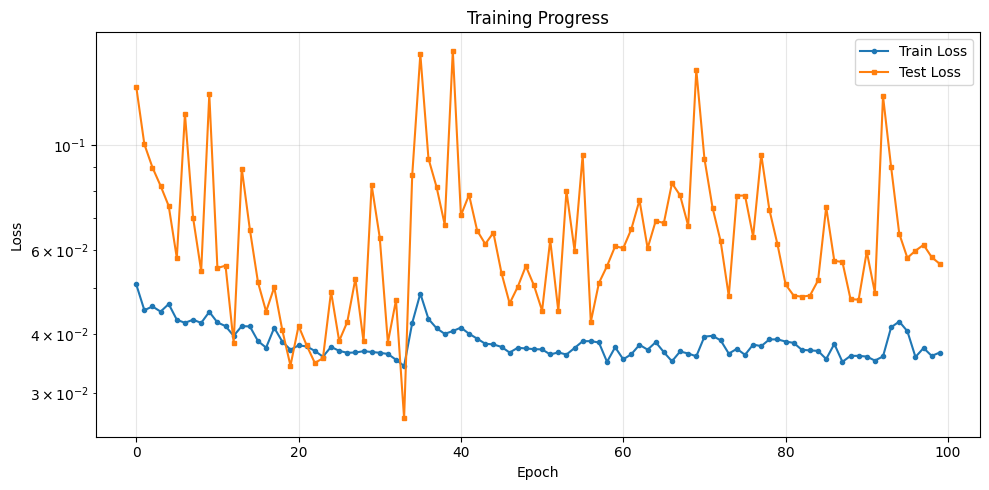


Final Train Loss: 0.036561
Final Test Loss: 0.056168


In [19]:
# Create outputs directory if it doesn't exist
import pathlib
outputs_dir = pathlib.Path("outputs")
outputs_dir.mkdir(exist_ok=True)

# Plot training and test losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(test_losses, label='Test Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale often helps visualize loss curves
plt.tight_layout()
plt.savefig('outputs/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Train Loss: {train_losses[-1]:.6f}")
print(f"Final Test Loss: {test_losses[-1]:.6f}")

## Evaluate Predictions

Let's evaluate the trained model on a test sample and compare predicted vs actual motor positions.

In [20]:
# Evaluate on test set
model.eval()

test_sample = test_dataset[0]
test_input = test_sample['inputs'].unsqueeze(0).to(device)
ground_truth_motors_norm = test_sample['motor_positions'].cpu().numpy()

# Predict
with torch.no_grad():
    predicted_motors_norm = model(test_input).squeeze().cpu().numpy()

# Denormalize
pred_motor_1, pred_motor_2 = test_dataset.denormalize_motors(
    predicted_motors_norm[0],
    predicted_motors_norm[1]
)

gt_motor_1, gt_motor_2 = test_dataset.denormalize_motors(
    ground_truth_motors_norm[0],
    ground_truth_motors_norm[1]
)

print("="*80)
print("TEST SAMPLE EVALUATION")
print("="*80)
print(f"\nMeasurement ID: {test_sample['metadata']['measurement_id']}")
print(f"Sun elevation: {test_sample['metadata']['sun_elevation']:.2f}°")
print(f"Sun azimuth: {test_sample['metadata']['sun_azimuth']:.2f}°")

print(f"\nGround Truth Motor Positions:")
print(f"  Motor 1: {gt_motor_1:.0f} increments")
print(f"  Motor 2: {gt_motor_2:.0f} increments")

print(f"\nPredicted Motor Positions:")
print(f"  Motor 1: {pred_motor_1:.0f} increments (error: {pred_motor_1 - gt_motor_1:.0f})")
print(f"  Motor 2: {pred_motor_2:.0f} increments (error: {pred_motor_2 - gt_motor_2:.0f})")

print(f"\nAbsolute Errors:")
print(f"  Motor 1: {abs(pred_motor_1 - gt_motor_1):.0f} increments")
print(f"  Motor 2: {abs(pred_motor_2 - gt_motor_2):.0f} increments")

if gt_motor_1 != 0 and gt_motor_2 != 0:
    print(f"\nRelative Errors:")
    print(f"  Motor 1: {abs(pred_motor_1 - gt_motor_1) / abs(gt_motor_1) * 100:.2f}%")
    print(f"  Motor 2: {abs(pred_motor_2 - gt_motor_2) / abs(gt_motor_2) * 100:.2f}%")

TEST SAMPLE EVALUATION

Measurement ID: 213875
Sun elevation: 60.90°
Sun azimuth: 14.80°

Ground Truth Motor Positions:
  Motor 1: 29486 increments
  Motor 2: 31300 increments

Predicted Motor Positions:
  Motor 1: 36055 increments (error: 6569)
  Motor 2: 27401 increments (error: -3899)

Absolute Errors:
  Motor 1: 6569 increments
  Motor 2: 3899 increments

Relative Errors:
  Motor 1: 22.28%
  Motor 2: 12.46%


## Save the Trained Model

In [21]:
# Create outputs directory
outputs_dir = pathlib.Path("outputs")
outputs_dir.mkdir(exist_ok=True)

# Save model checkpoint
model_path = outputs_dir / "motor_predictor_model.pt"
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'test_losses': test_losses,
    'normalization_stats': {
        'motor_1_min': train_dataset.motor_1_min,
        'motor_1_max': train_dataset.motor_1_max,
        'motor_2_min': train_dataset.motor_2_min,
        'motor_2_max': train_dataset.motor_2_max,
    }
}, model_path)

print(f"✓ Model saved to: {model_path}")
print(f"  File size: {model_path.stat().st_size / 1024 / 1024:.2f} MB")

✓ Model saved to: outputs/motor_predictor_model.pt
  File size: 192.49 MB


## Summary and Next Steps

**What you've accomplished:**
1. ✓ Loaded calibration data from paint_data/AA31/Calibration folder
2. ✓ Filtered measurements targeting solar_tower_juelich_lower (53 samples)
3. ✓ Implemented 80-20 train-test split
4. ✓ Created PyTorch Dataset with sun angles + flux images as inputs
5. ✓ Defined a neural network for motor position prediction
6. ✓ Implemented training loop with ARTIST flux-based loss
7. ✓ Trained the model and evaluated predictions

**Current Training Configuration:**
- **Dataset:** 53 measurements from AA31 heliostat targeting solar_tower_juelich_lower
- **Train/Test Split:** 80-20 (~42 training, ~11 test samples)
- **Input Features:** 2 sun angles + 65,536 flux pixels = 65,538 total
- **Output:** 2 motor positions (axis 1 and axis 2)
- **Loss Function:** MSE loss on flux images + motor position regularization
- **Training Mode:** Flux-based with ARTIST raytracing

**Next steps to improve the pipeline:**

1. **Increase Dataset Size:**
   - Add measurements from other targets (solar_tower_juelich_upper, multi_focus_tower)
   - Add other heliostats from paint_data folder
   - Generate synthetic training data with data augmentation

2. **Improve Network Architecture:**
   - Use convolutional layers to process flux images (currently flattened)
   - Add separate encoders for sun angles and flux images
   - Experiment with deeper networks or residual connections
   - Try attention mechanisms to focus on important flux regions

3. **Advanced Loss Functions:**
   - Use ARTIST's KLDivergenceLoss for better distribution matching
   - Add focal loss to focus on difficult samples
   - Weighted combination of multiple loss terms

4. **Training Improvements:**
   - Increase batch size (currently 1) for more stable gradients
   - Add learning rate scheduling (e.g., ReduceLROnPlateau)
   - Implement early stopping to prevent overfitting
   - Add gradient clipping for training stability

5. **Hyperparameter Tuning:**
   - Experiment with different learning rates
   - Try different network architectures (wider, deeper)
   - Adjust the weight of motor position regularization

6. **Validation and Visualization:**
   - Compare predicted vs ground truth flux images side-by-side
   - Plot motor position predictions vs ground truth
   - Analyze errors by sun angle ranges
   - Visualize learned features in hidden layers

7. **Multi-Heliostat Generalization:**
   - Train on multiple heliostats simultaneously
   - Add heliostat-specific features (position, actuator parameters)
   - Test transfer learning to new heliostats